<a href="https://colab.research.google.com/github/rsr-28/growth_model_dp/blob/main/MACRO_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Converged in 25 iterations.

--- Numerical Solution ---
Numerical Steady-State Capital (k*): 0.1032
Numerical Steady-State Consumption (c*): 0.4234
Numerical Value Function (v(k*)): -2.1489
Numerical Policy Function (g(k*)): 0.1032

--- Analytical Solution ---
Analytical Steady-State Capital (k*): 0.1036
Analytical Steady-State Consumption (c*): 0.4237


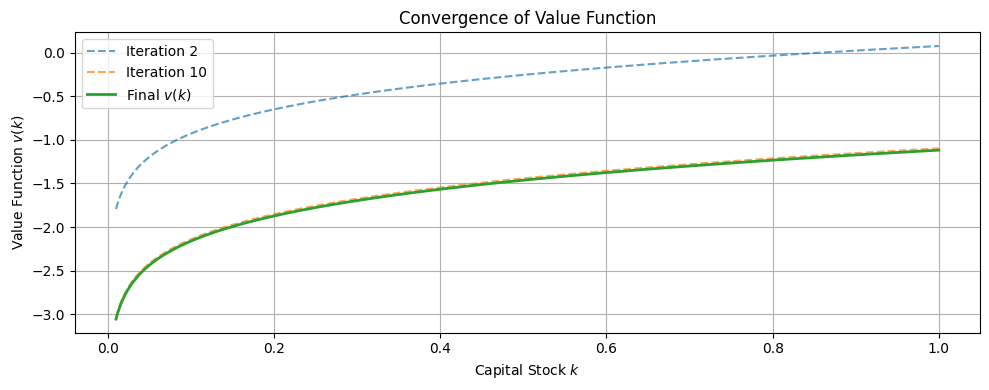

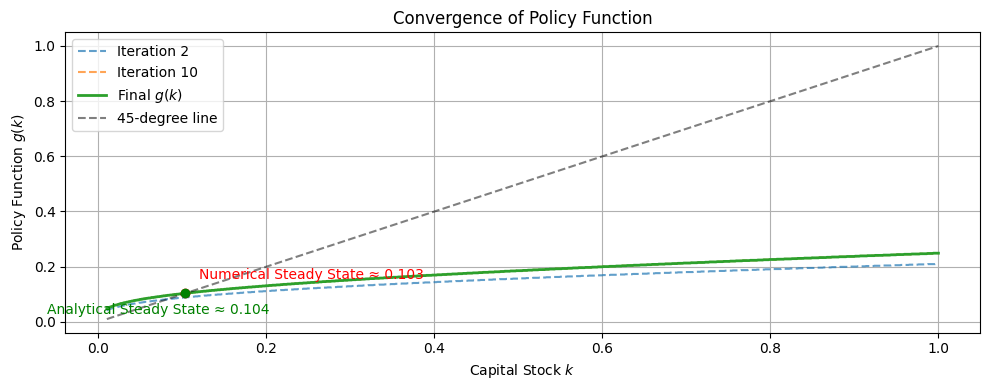

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


alpha = 0.3
beta = 0.6
delta = 0.8

N = 1000
k_min = 0.01
k_max = 1.0
k_grid = np.linspace(k_min, k_max, N)

np.random.seed(0)
v = np.random.rand(N)
policy_k = np.zeros(N)

v_iter = {}
g_iter = {}

tolerance = 1e-5
max_iter = 1000
diff = 1
iter_count = 0

while diff > tolerance and iter_count < max_iter:
    v_new = np.zeros_like(v)
    policy_new = np.zeros_like(policy_k)

    for i, k in enumerate(k_grid):
        output = k**alpha + (1 - delta) * k
        value_vec = []

        for j, k_prime in enumerate(k_grid):
            c = output - k_prime
            if c > 0:
                val = np.log(c) + beta * v[j]
            else:
                val = -np.inf
            value_vec.append(val)

        v_new[i] = max(value_vec)
        policy_new[i] = k_grid[np.argmax(value_vec)]

    diff = np.max(np.abs(v_new - v))
    v = v_new
    policy_k = policy_new
    iter_count += 1

    if iter_count in [2, 10]:
        v_iter[iter_count] = v.copy()
        g_iter[iter_count] = policy_k.copy()

v_iter["final"] = v
g_iter["final"] = policy_k

print(f"Converged in {iter_count} iterations.")

steady_state_index = np.argmin(np.abs(policy_k - k_grid))  # Find where policy_k ≈ k
steady_state_k = k_grid[steady_state_index]

steady_state_output = steady_state_k**alpha + (1 - delta) * steady_state_k
steady_state_c = steady_state_output - steady_state_k

steady_state_v = v[steady_state_index]

steady_state_policy = policy_k[steady_state_index]

print("\n--- Numerical Solution ---")
print(f"Numerical Steady-State Capital (k*): {steady_state_k:.4f}")
print(f"Numerical Steady-State Consumption (c*): {steady_state_c:.4f}")
print(f"Numerical Value Function (v(k*)): {steady_state_v:.4f}")
print(f"Numerical Policy Function (g(k*)): {steady_state_policy:.4f}")

k_star_analytical = (1 / alpha * (1 / beta - (1 - delta))) ** (1 / (alpha - 1))
c_star_analytical = k_star_analytical**alpha - delta * k_star_analytical

print("\n--- Analytical Solution ---")
print(f"Analytical Steady-State Capital (k*): {k_star_analytical:.4f}")
print(f"Analytical Steady-State Consumption (c*): {c_star_analytical:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(k_grid, v_iter[2], '--', label="Iteration 2", alpha=0.7)
plt.plot(k_grid, v_iter[10], '--', label="Iteration 10", alpha=0.7)
plt.plot(k_grid, v_iter["final"], label="Final $v(k)$", linewidth=2)
plt.xlabel("Capital Stock $k$")
plt.ylabel("Value Function $v(k)$")
plt.title("Convergence of Value Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(k_grid, g_iter[2], '--', label="Iteration 2", alpha=0.7)
plt.plot(k_grid, g_iter[10], '--', label="Iteration 10", alpha=0.7)
plt.plot(k_grid, g_iter["final"], label="Final $g(k)$", linewidth=2)

plt.plot(k_grid, k_grid, 'k--', alpha=0.5, label="45-degree line")

plt.scatter(steady_state_k, steady_state_policy, color='red', zorder=5)
plt.annotate(f"Numerical Steady State ≈ {steady_state_k:.3f}",
             (steady_state_k, steady_state_policy),
             textcoords="offset points", xytext=(10,10), ha='left', color='red')

plt.scatter(k_star_analytical, k_star_analytical, color='green', zorder=5)
plt.annotate(f"Analytical Steady State ≈ {k_star_analytical:.3f}",
             (k_star_analytical, k_star_analytical),
             textcoords="offset points", xytext=(-100,-15), ha='left', color='green')

plt.xlabel("Capital Stock $k$")
plt.ylabel("Policy Function $g(k)$")
plt.title("Convergence of Policy Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
